In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps

sys.path.append("C:/Users/haoyu/Documents/GitHub/XRaySimulation")

from XRaySimulation import Pulse, DeviceSimu, util, Crystal

In [3]:
bLattice = np.zeros((11, 11, 11, 360, 3))

bLattice[:,:,:,:,0] = np.arange(-5, 6)[:, np.newaxis, np.newaxis, np.newaxis] * np.pi * 2 / 10.518 * 1e4
bLattice[:,:,:,:,1] = np.arange(-5, 6)[np.newaxis, :, np.newaxis, np.newaxis] * np.pi * 2 / 10.518 * 1e4
bLattice[:,:,:,:,2] = np.arange(-5, 6)[np.newaxis, np.newaxis, :, np.newaxis] * np.pi * 2 / 10.518 * 1e4

tilt_angle = np.deg2rad(-5)
tilt_mat = np.array([
    [1, 0, 0,],
    [0, np.cos(tilt_angle), -np.sin(tilt_angle)],
    [0, np.sin(tilt_angle), np.cos(tilt_angle)],
])

for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            for idx in range(360):
                angle = np.deg2rad(idx)
                rot_mat = np.array([[np.cos(angle), 0, -np.sin(angle)],
                                    [0, 1, 0],
                                    [np.sin(angle), 0, np.cos(angle)],])
                
                bLattice[xIdx, yIdx, zIdx, idx, :] = np.dot(tilt_mat, np.dot(rot_mat, bLattice[xIdx, yIdx, zIdx, idx]))

In [7]:
kLen = util.kev_to_wavevec_length(9.8)
angle = np.deg2rad(11.639) * 2
kvec = np.array([-np.sin(angle), 0, np.cos(angle)]) * kLen

tg_angle = np.deg2rad(0.7)
kvec_tg = np.copy(kvec)
kvec_tg[1] += 2 * np.sin(tg_angle) * kLen

In [8]:
kout = bLattice + kvec_tg[np.newaxis, np.newaxis, np.newaxis, np.newaxis]
kout_len = np.linalg.norm(kout, axis=-1)
kout_len_diff = kout_len - kLen

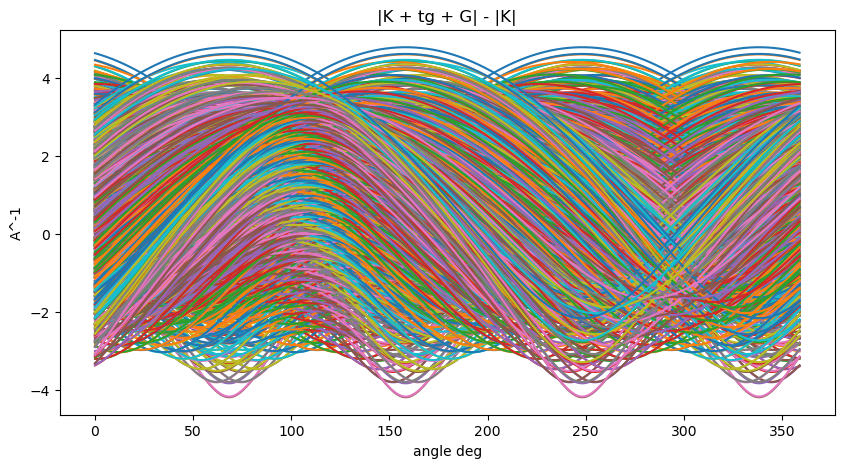

In [11]:
fig, ax = plt.subplots(ncols=1,nrows=1)
cmap = colormaps['summer']

fig.set_figheight(5)
fig.set_figwidth(10)

for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            ax.plot(np.arange(360), kout_len_diff[xIdx, yIdx, zIdx] / 1e4,
                    label="G=({}, {}, {})".format(xIdx, yIdx, zIdx))

plt.title('|K + tg + G| - |K|')
plt.ylabel("A^-1")
plt.xlabel('angle deg')
#plt.legend()
plt.show()

In [15]:
for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            x = np.argmin(np.abs(kout_len_diff[xIdx, yIdx, zIdx] / 1e4))
            print("G=({}, {}, {})".format(xIdx, yIdx, zIdx), x)
            print("G=({}, {}, {})".format(xIdx, yIdx, zIdx), kout[xIdx, yIdx, zIdx, x])
        
            print('------------------------------')

G=(0, 0, 0) 21
G=(0, 0, 0) [-36807.6258569  -31904.82267002   9782.26205227]
------------------------------
G=(0, 0, 1) 123
G=(0, 0, 1) [ 16680.93013414 -29590.57881406  36234.19036715]
------------------------------
G=(0, 0, 2) 131
G=(0, 0, 2) [ 13494.21442961 -29481.54202077  37480.48661742]
------------------------------
G=(0, 0, 3) 43
G=(0, 0, 3) [-33323.19639545 -31078.53491743  19226.77428145]
------------------------------
G=(0, 0, 4) 53
G=(0, 0, 4) [-32831.3649086  -30933.94801332  20879.41015777]
------------------------------
G=(0, 0, 5) 162
G=(0, 0, 5) [  8780.08527246 -29346.02518383  39029.4511516 ]
------------------------------
G=(0, 0, 6) 76
G=(0, 0, 6) [-32648.9601715  -30941.53078925  20792.73863227]
------------------------------
G=(0, 0, 7) 184
G=(0, 0, 7) [ 11002.62089922 -29398.74621457  38426.84701278]
------------------------------
G=(0, 0, 8) 193
G=(0, 0, 8) [ 13507.83218739 -29477.88922346  37522.23828176]
------------------------------
G=(0, 0, 9) 200
G=(0, 0

In [22]:
for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            x = np.argmin(np.abs(kout_len_diff[xIdx, yIdx, zIdx] / 1e4))
            k_tmp = kout[xIdx, yIdx, zIdx, x]
            
            if kout_len_diff[xIdx, yIdx, zIdx, x - 1] *  kout_len_diff[xIdx, yIdx, zIdx, x + 1] < 0:
                
                if k_tmp[0] > 0 and k_tmp[1] > 0 and k_tmp[2] > 0:
                    print("G=({}, {}, {})".format(xIdx - 5, yIdx - 5, zIdx - 5), kout[xIdx, yIdx, zIdx, x], x + 1)
            
                    # Normalize the wave-vector
                    direction = k_tmp / np.linalg.norm(k_tmp)
            
                    # Get the position
                    position = direction / direction[2] * 12
                    
                    print("detector positoin with respect to the sample in cm", position)
                    print('------------------------------')
    


G=(-5, 0, -5) [22588.26448119  1085.00107263 44152.46998033] 134
detector positoin with respect to the sample in cm [ 6.13916218  0.29488753 12.        ]
------------------------------
G=(-5, 0, -4) [18621.33535921  1251.87461018 46059.84324254] 143
detector positoin with respect to the sample in cm [ 4.85142824  0.32615168 12.        ]
------------------------------
G=(-5, 0, -2) [12429.95170196  1448.16622303 48303.46664402] 164
detector positoin with respect to the sample in cm [ 3.08796513  0.35976703 12.        ]
------------------------------
G=(-5, 0, -1) [10702.76720857  1459.16674368 48429.20317043] 175
detector positoin with respect to the sample in cm [ 2.65197852  0.36155872 12.        ]
------------------------------
G=(-5, 0, 1) [10683.39760484  1476.69908232 48629.59871802] 198
detector positoin with respect to the sample in cm [ 2.63627039  0.36439513 12.        ]
------------------------------
G=(-5, 0, 4) [18623.19738845  1233.27841445 45847.28775268] 220
detector pos

IndexError: index 360 is out of bounds for axis 3 with size 360